# Step 4: Final Inference Pipeline (Advanced SBI)
This is the final inference pipeline used for the report. It integrates several advanced techniques:
1. **Mahalanobis Distance**: To decorrelate the 5D summary statistics space.
2. **Local Linear Regression Adjustment**: To correct for tolerance-induced bias and sharpen the posterior distribution.
3. **Posterior Predictive Checks (PPC)**: To validate the model's performance against observed data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from simulator_fast import simulate_fast
from scipy.stats import multivariate_normal
import time

In [4]:
# Load observed data from the 'data' directory
obs_infected = pd.read_csv('data/infected_timeseries.csv')
obs_rewiring = pd.read_csv('data/rewiring_timeseries.csv')
obs_degrees = pd.read_csv('data/final_degree_histograms.csv')

In [7]:
# ---------------------------------------------------------
# 1. Compute summary statistics from the observed data
# ---------------------------------------------------------

# Infection AUC (Area Under the Curve) - Total cumulative infection pressure
auc_per_rep = obs_infected.groupby('replicate_id')['infected_fraction'].sum().values

# Standard stats: Peak infected fraction and Total number of rewires
peaks_per_rep = obs_infected.groupby('replicate_id')['infected_fraction'].max().values
rewires_per_rep = obs_rewiring.groupby('replicate_id')['rewire_count'].sum().values

# --- NEW FEATURE: Maximum Step Rewire Rate ---
# This captures the "burstiness" or intensity of the behavioral response.
# High Rho scenarios show a sharp spike in rewiring at the epidemic peak.
max_rewires_per_rep = obs_rewiring.groupby('replicate_id')['rewire_count'].max().values

# CENTER OF MASS (Infection Timing) - Weighted average of time steps by infection levels
def get_weighted_time(group):
    times = group['time'].values
    fractions = group['infected_fraction'].values
    if np.sum(fractions) == 0: return 1e-6
    return np.sum(times * fractions) / np.sum(fractions)

weighted_time_per_rep = obs_infected.groupby('replicate_id').apply(get_weighted_time).values

# DEGREE VARIANCE (Topology) - Captures the final network structure heterogeneity
obs_degrees['deg_x_count'] = obs_degrees['degree'] * obs_degrees['count']
obs_degrees['deg2_x_count'] = (obs_degrees['degree']**2) * obs_degrees['count']
mean_deg_per_rep = obs_degrees.groupby('replicate_id')['deg_x_count'].sum() / 200
var_deg_per_rep = (obs_degrees.groupby('replicate_id')['deg2_x_count'].sum() / 200) - mean_deg_per_rep**2
var_deg_per_rep = var_deg_per_rep.values

# --- FEATURE UPGRADE: Rewire-to-Infection Ratio ---
# This captures "How aggressively people flee per unit of infection risk"
# Differentiates high-effort/short-duration from low-effort/long-duration scenarios.
rewire_ratio_per_rep = rewires_per_rep / np.maximum(auc_per_rep, 1e-6)

# ---------------------------------------------------------
# 2. Log-transform and build the Feature Matrix (40x5)
# ---------------------------------------------------------
# We now use 5 summary statistics to break the beta-rho equifinality
target_peaks = peaks_per_rep
target_log_ratio = np.log(np.maximum(rewire_ratio_per_rep, 1e-6))
target_log_var_deg = np.log(np.maximum(var_deg_per_rep, 1e-6))
target_log_time = np.log(np.maximum(weighted_time_per_rep, 1e-6))
target_log_max_rewire = np.log(np.maximum(max_rewires_per_rep, 1e-6)) # Added max rewire rate

# Construct the final 40 replicates x 5 summary statistics matrix
X_log_final = np.column_stack([
    target_peaks, 
    target_log_ratio, 
    target_log_var_deg, 
    target_log_time,
    target_log_max_rewire
])

# ---------------------------------------------------------
# 3. Final Target Mu and Std for SMC-ABC (5-dimensional)
# ---------------------------------------------------------
target_mu = np.mean(X_log_final, axis=0)
target_std = np.std(X_log_final, axis=0) 

print("=== NEW 5-Feature Targets (Decoupling Beta & Rho) ===")
print("Features: [Peak, Log Ratio, Log Degree Var, Log Timing, Log Max Rewire]")
print(f"Target Mu : {target_mu}")
print(f"Target Std: {target_std}")

# ---------------------------------------------------------
# 4. Covariance Matrix and its Inverse for Mahalanobis Distance
# ---------------------------------------------------------
# Calculate the covariance matrix across the 40 replicates (5 features)
target_cov = np.cov(X_log_final, rowvar=False)

# Calculate the inverse covariance matrix (precision matrix)
target_cov_inv = np.linalg.inv(target_cov)

print("=== Mahalanobis Distance Components ===")
print("Inverse Covariance Matrix Shape:", target_cov_inv.shape)

=== NEW 5-Feature Targets (Decoupling Beta & Rho) ===
Features: [Peak, Log Ratio, Log Degree Var, Log Timing, Log Max Rewire]
Target Mu : [0.657125   3.86790725 2.32915881 2.84395716 4.58092127]
Target Std: [0.04212908 0.10240734 0.11783298 0.09236541 0.10346412]
=== Mahalanobis Distance Components ===
Inverse Covariance Matrix Shape: (5, 5)


In [10]:
# ---------------------------------------------------------
# 2. SMC-ABC Parameters
# ---------------------------------------------------------
n_particles = 1000  # 1000 particles is usually sufficient for ABC
# Gradually decreasing tolerance (Epsilon)
# The first stage is easy to pass, the final stage is the tightest
epsilons = [5.0, 3.0, 2.0, 1.5] 

# Prior definitions (Uniform)
prior_bounds = np.array([
    [0.05, 0.50],  # beta
    [0.02, 0.20],  # gamma
    [0.0, 0.80]    # rho
])

def prior_pdf(theta):
    if (prior_bounds[0,0] <= theta[0] <= prior_bounds[0,1] and 
        prior_bounds[1,0] <= theta[1] <= prior_bounds[1,1] and 
        prior_bounds[2,0] <= theta[2] <= prior_bounds[2,1]):
        return 1.0 / np.prod(prior_bounds[:, 1] - prior_bounds[:, 0])
    return 0.0

# --- UPDATED: Mahalanobis Distance Function ---
def calculate_distance_mahalanobis(sim_stats, target_mu, target_cov_inv):
    """
    Calculate the Mahalanobis distance between simulated stats and target mu.
    """
    # Difference vector
    diff = sim_stats - target_mu
    
    # Mahalanobis distance calculation
    dist_sq = np.dot(np.dot(diff, target_cov_inv), diff)
    
    # Prevent negative values due to floating-point arithmetic errors
    return np.sqrt(max(dist_sq, 0.0))

In [11]:
# ---------------------------------------------------------
# 3. SMC-ABC Core Loop
# ---------------------------------------------------------
np.random.seed(100)  # For reproducibility

print("--- Starting SMC-ABC ---")
particles_history = []
weights_history = []

for gen, eps in enumerate(epsilons):
    start_time = time.time()
    new_particles = np.zeros((n_particles, 3))
    new_weights = np.zeros(n_particles)
    accepted_count = 0
    attempts = 0
    
    if gen > 0:
        # Calculate covariance of previous particles for perturbation
        prev_particles = particles_history[-1]
        prev_weights = weights_history[-1]
        # Weighted covariance matrix * factor (usually 2.0 for exploring)
        cov_matrix = np.cov(prev_particles.T, aweights=prev_weights) * 2.0
    
    while accepted_count < n_particles:
        attempts += 1
        
        # A. Propose a new parameter
        if gen == 0:
            # Gen 0: Sample from prior
            theta_prop = np.array([
                np.random.uniform(prior_bounds[0,0], prior_bounds[0,1]),
                np.random.uniform(prior_bounds[1,0], prior_bounds[1,1]),
                np.random.uniform(prior_bounds[2,0], prior_bounds[2,1])
            ])
        else:
            # Gen > 0: Resample from previous generation and perturb
            idx = np.random.choice(n_particles, p=prev_weights)
            theta_parent = prev_particles[idx]
            theta_prop = np.random.multivariate_normal(theta_parent, cov_matrix)
            
            # Check if out of prior bounds
            if prior_pdf(theta_prop) == 0:
                continue
                
        # B. Run Simulation
        sim_infected, sim_rewires, sim_degrees = simulate_fast(theta_prop[0], theta_prop[1], theta_prop[2])
        
        # C. Calculate Summary Statistics (5-dimensional vector)
        # 1. Peak Infected Fraction
        sim_peak = np.max(sim_infected)
        
        # 2. Rewire-to-Infection Ratio (Log)
        sum_inf = np.sum(sim_infected)
        s_auc = np.maximum(sum_inf, 1e-6) # Guard against zero division
        sim_rewires_tot = np.sum(sim_rewires)
        sim_ratio = sim_rewires_tot / s_auc
        sim_log_ratio = np.log(np.maximum(sim_ratio, 1e-6))
        
        # 3. Final Degree Variance (Log)
        degrees_arr = np.arange(31)
        sim_mean_deg = np.sum(degrees_arr * sim_degrees) / 200
        sim_var_deg = np.sum((degrees_arr**2) * sim_degrees) / 200 - sim_mean_deg**2
        sim_log_var_deg = np.log(np.maximum(sim_var_deg, 1e-6))
        
        # 4. Weighted Infection Timing (Log)
        if sum_inf > 0:
            times_arr = np.arange(len(sim_infected))
            sim_weighted_time = np.sum(times_arr * sim_infected) / sum_inf
        else:
            sim_weighted_time = 1e-6
        sim_log_time = np.log(sim_weighted_time)

        # --- NEW: 5. Maximum Step Rewire Rate (Log) ---
        # Captures the instantaneous intensity of the behavioral response
        sim_max_rewire = np.max(sim_rewires)
        sim_log_max_rewire = np.log(np.maximum(sim_max_rewire, 1e-6))
        
        # --- UPDATED: Construct the 5-feature stats array ---
        sim_stats = np.array([
            sim_peak, 
            sim_log_ratio, 
            sim_log_var_deg, 
            sim_log_time, 
            sim_log_max_rewire
        ])
        
        # D. Calculate Distance using Mahalanobis
        distance = calculate_distance_mahalanobis(sim_stats, target_mu, target_cov_inv)
        
        # E. Accept or Reject
        if distance < eps:
            new_particles[accepted_count] = theta_prop
            
            # F. Calculate Weight
            if gen == 0:
                new_weights[accepted_count] = 1.0
            else:
                # Beaumont et al. (2009) weight update formula
                prior_val = prior_pdf(theta_prop)
                # Using the symmetric Gaussian kernel for perturbation
                kernel_vals = multivariate_normal.pdf(prev_particles, mean=theta_prop, cov=cov_matrix)
                denominator = np.sum(prev_weights * kernel_vals)
                new_weights[accepted_count] = prior_val / denominator
                
            accepted_count += 1
            
            if accepted_count % 250 == 0:
                print(f"  Accepted {accepted_count}/{n_particles} (Attempts: {attempts})")

    # Normalize weights
    new_weights = new_weights / np.sum(new_weights)
    
    particles_history.append(new_particles.copy())
    weights_history.append(new_weights.copy())
    
    elapsed = time.time() - start_time
    print(f"Generation {gen} completed. Epsilon: {eps} | Time: {elapsed:.1f}s | Acceptance Rate: {n_particles/attempts:.2%}")

--- Starting SMC-ABC ---
  Accepted 250/1000 (Attempts: 8647)
  Accepted 500/1000 (Attempts: 16529)
  Accepted 750/1000 (Attempts: 24411)
  Accepted 1000/1000 (Attempts: 32149)
Generation 0 completed. Epsilon: 5.0 | Time: 58.0s | Acceptance Rate: 3.11%
  Accepted 250/1000 (Attempts: 6377)
  Accepted 500/1000 (Attempts: 13655)
  Accepted 750/1000 (Attempts: 20486)
  Accepted 1000/1000 (Attempts: 26600)
Generation 1 completed. Epsilon: 3.0 | Time: 30.7s | Acceptance Rate: 3.76%
  Accepted 250/1000 (Attempts: 8963)
  Accepted 500/1000 (Attempts: 18084)
  Accepted 750/1000 (Attempts: 29312)
  Accepted 1000/1000 (Attempts: 39332)
Generation 2 completed. Epsilon: 2.0 | Time: 52.3s | Acceptance Rate: 2.54%
  Accepted 250/1000 (Attempts: 16730)
  Accepted 500/1000 (Attempts: 31556)
  Accepted 750/1000 (Attempts: 45896)
  Accepted 1000/1000 (Attempts: 62701)
Generation 3 completed. Epsilon: 1.5 | Time: 87.5s | Acceptance Rate: 1.59%



Generating Pairwise Plots for SMC-ABC Final Generation...
Saved pairplot to: plots/smc_abc_pairplot_s5_mahalanobis.pdf


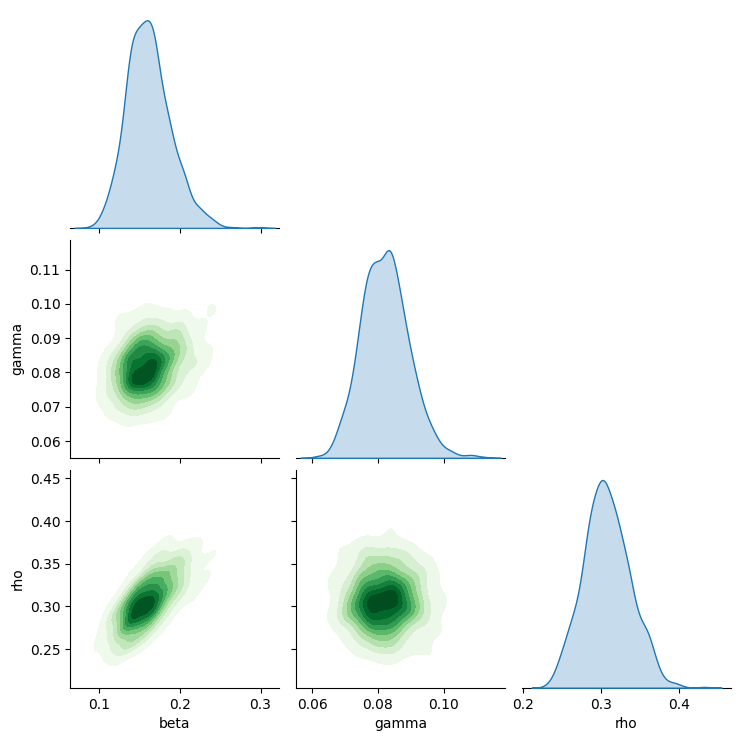

In [12]:
# ---------------------------------------------------------
# 4. Final Posterior Visualization
# ---------------------------------------------------------
final_particles = particles_history[-1]
df_posterior_smc = pd.DataFrame(final_particles, columns=['beta', 'gamma', 'rho'])

print("\nGenerating Pairwise Plots for SMC-ABC Final Generation...")
g = sns.pairplot(df_posterior_smc, kind='kde', corner=True, 
                plot_kws={'fill': True, 'cmap': 'Greens'}) 

pairplot_path = 'plots/smc_abc_pairplot_s5_mahalanobis.pdf'
g.savefig(pairplot_path, format='pdf', bbox_inches='tight')
print(f"Saved pairplot to: {pairplot_path}")

plt.show()

In [13]:
# ---------------------------------------------------------
# 1. Extract extreme parameter sets from the SMC posterior
# ---------------------------------------------------------
# Sort the dataframe by 'beta' to easily find the extremes of the ridge
df_sorted = df_posterior_smc.sort_values(by='beta')

# Select 5 particles with the lowest beta (and consequently lowest rho)
# Extract only the first 3 columns: ['beta', 'gamma', 'rho']
low_params = df_sorted.iloc[:, :3].head(5).values

# Select 5 particles with the highest beta (and consequently highest rho)
high_params = df_sorted.iloc[:, :3].tail(5).values

Simulating dynamics for Low Beta / Low Rho group...
Simulating dynamics for High Beta / High Rho group...
Saved resolved equifinality plot to: plots/smc_abc_SIR_plot_4.pdf


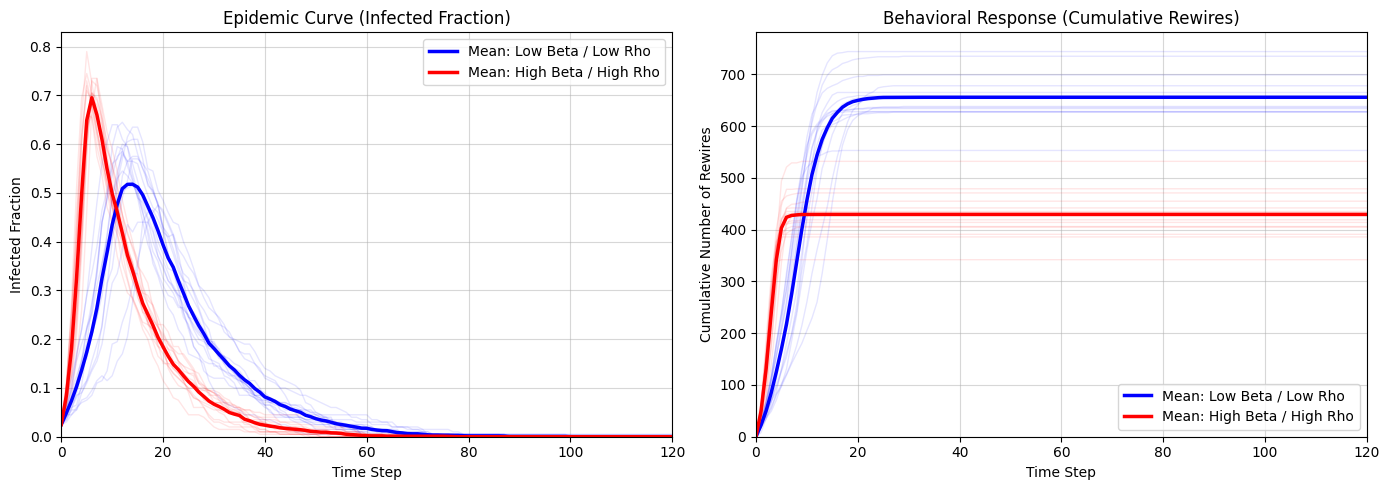

In [14]:
# ---------------------------------------------------------
# 2. Setup the side-by-side plots (1x2 layout)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

low_infected_all, low_rewires_all = [], []
high_infected_all, high_rewires_all = [], []

print("Simulating dynamics for Low Beta / Low Rho group...")
# 3. Simulate and plot for the 'Low beta, Low rho' group
for i, (beta, gamma, rho) in enumerate(low_params):
    for j in range(3):
        sim_infected, sim_rewires, _ = simulate_fast(beta, gamma, rho)
        
        low_infected_all.append(sim_infected)
        low_rewires_all.append(np.cumsum(sim_rewires))
        
        axes[0].plot(sim_infected, color='blue', alpha=0.1, linewidth=1)
        axes[1].plot(np.cumsum(sim_rewires), color='blue', alpha=0.1, linewidth=1)

print("Simulating dynamics for High Beta / High Rho group...")
# 4. Simulate and plot for the 'High beta, High rho' group
for i, (beta, gamma, rho) in enumerate(high_params):
    for j in range(3):
        sim_infected, sim_rewires, _ = simulate_fast(beta, gamma, rho)
        
        high_infected_all.append(sim_infected)
        high_rewires_all.append(np.cumsum(sim_rewires))

        axes[0].plot(sim_infected, color='red', alpha=0.1, linewidth=1)
        axes[1].plot(np.cumsum(sim_rewires), color='red', alpha=0.1, linewidth=1)

# ---------------------------------------------------------
# 4.5. Calculate and plot Mean lines (alpha = 1)
# ---------------------------------------------------------
time_steps = np.arange(len(low_infected_all[0]))

mean_low_infected = np.mean(low_infected_all, axis=0)
mean_low_rewires = np.mean(low_rewires_all, axis=0)
axes[0].plot(time_steps, mean_low_infected, color='blue', alpha=1.0, linewidth=2.5, label='Mean: Low Beta / Low Rho')
axes[1].plot(time_steps, mean_low_rewires, color='blue', alpha=1.0, linewidth=2.5, label='Mean: Low Beta / Low Rho')

mean_high_infected = np.mean(high_infected_all, axis=0)
mean_high_rewires = np.mean(high_rewires_all, axis=0)
axes[0].plot(time_steps, mean_high_infected, color='red', alpha=1.0, linewidth=2.5, label='Mean: High Beta / High Rho')
axes[1].plot(time_steps, mean_high_rewires, color='red', alpha=1.0, linewidth=2.5, label='Mean: High Beta / High Rho')

# ---------------------------------------------------------
# 5. Finalize plot aesthetics
# ---------------------------------------------------------
# Left plot formatting
axes[0].set_title('Epidemic Curve (Infected Fraction)')
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Infected Fraction')
axes[0].set_xlim(0, 120)       
axes[0].set_ylim(bottom=0)     
axes[0].margins(x=0, y=0)      
axes[0].legend()
axes[0].grid(True, alpha=0.5)

# Right plot formatting
axes[1].set_title('Behavioral Response (Cumulative Rewires)')
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Cumulative Number of Rewires')
axes[1].set_xlim(0, 120)       
axes[1].set_ylim(bottom=0)     
axes[1].margins(x=0, y=0)      
axes[1].legend()
axes[1].grid(True, alpha=0.5)

plt.tight_layout()

# Save the plot for the report
plt.savefig('plots/smc_abc_SIR_plot_4.pdf', format='pdf', bbox_inches='tight')
print("Saved resolved equifinality plot to: plots/smc_abc_SIR_plot_4.pdf")

plt.show()

In [16]:
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

print("--- Starting Regression Adjustment ---")

# 1. Extract the accepted parameters from the final SMC generation
theta_accepted = df_posterior_smc[['beta', 'gamma', 'rho']].values
n_accepted = len(theta_accepted)
sim_stats_accepted = np.zeros((n_accepted, 5))

# 2. Simulate for each accepted parameter set and compute summary statistics
start_time = time.time()
for i, (beta, gamma, rho) in enumerate(theta_accepted):
    sim_infected, sim_rewires, sim_degrees = simulate_fast(beta, gamma, rho)
    
    sim_peak = np.max(sim_infected)
    
    sum_inf = np.sum(sim_infected)
    s_auc = np.maximum(sum_inf, 1e-6)
    sim_log_ratio = np.log(np.maximum(np.sum(sim_rewires) / s_auc, 1e-6))
    
    degrees_arr = np.arange(31)
    sim_mean_deg = np.sum(degrees_arr * sim_degrees) / 200
    sim_var_deg = np.sum((degrees_arr**2) * sim_degrees) / 200 - sim_mean_deg**2
    sim_log_var_deg = np.log(np.maximum(sim_var_deg, 1e-6))
    
    if sum_inf > 0:
        times_arr = np.arange(len(sim_infected))
        sim_weighted_time = np.sum(times_arr * sim_infected) / sum_inf
    else:
        sim_weighted_time = 1e-6
    sim_log_time = np.log(sim_weighted_time)

    sim_log_max_rewire = np.log(np.maximum(np.max(sim_rewires), 1e-6))
    
    sim_stats_accepted[i] = [sim_peak, sim_log_ratio, sim_log_var_deg, sim_log_time, sim_log_max_rewire]

# 3. Fit a linear regression model to predict parameters from summary statistics
# Explanatory variables: Simulation summary statistics (X)
# Response variables: Parameters (Y)
reg = LinearRegression()
reg.fit(sim_stats_accepted, theta_accepted)

# 4. Calculate the adjusted parameters using the regression model
# If the simulated stats had perfectly matched the target (reality), what would the parameters have been?
# Adjustment formula: theta_adj = theta_sim - (predicted_theta_sim - predicted_true_theta)
pred_sim = reg.predict(sim_stats_accepted)
pred_target = reg.predict(target_mu.reshape(1, -1))

theta_adjusted = theta_accepted - pred_sim + pred_target

# 5. Store the adjusted data in a DataFrame
df_adjusted = pd.DataFrame(theta_adjusted, columns=['beta', 'gamma', 'rho'])

# Note: Regression adjustment can sometimes produce parameter values outside the prior bounds (e.g., negative beta or rho). We will filter
df_adjusted = df_adjusted[
    (df_adjusted['beta'] > 0) & 
    (df_adjusted['gamma'] > 0) & 
    (df_adjusted['rho'] > 0)
]

elapsed = time.time() - start_time
print(f"Regression Adjustment completed in {elapsed:.1f}s.")
print(f"Valid adjusted particles: {len(df_adjusted)} / {n_accepted}")

--- Starting Regression Adjustment ---
Regression Adjustment completed in 1.4s.
Valid adjusted particles: 1000 / 1000



Generating Pairwise Plots for Regression-Adjusted Posterior...
Saved pairplot to: plots/smc_abc_pairplot_s5_regression_adjusted.pdf


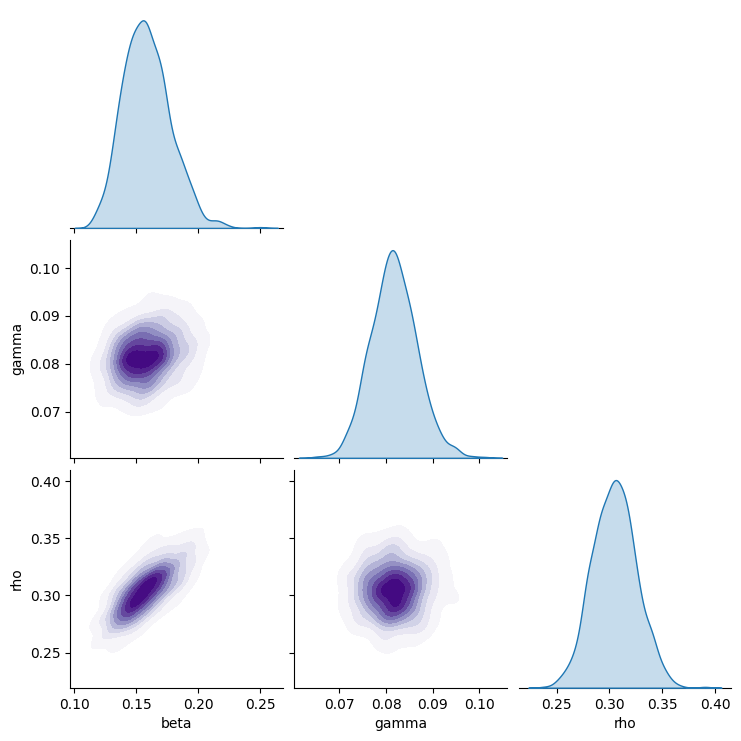

In [17]:
# ---------------------------------------------------------
# 4. Final Posterior Visualization (After Regression Adjustment)
# ---------------------------------------------------------
# Use the df_adjusted (regression-adjusted data) to create the pairwise plots

print("\nGenerating Pairwise Plots for Regression-Adjusted Posterior...")
g = sns.pairplot(df_adjusted, kind='kde', corner=True, 
                plot_kws={'fill': True, 'cmap': 'Purples'}) 

pairplot_path = 'plots/smc_abc_pairplot_s5_regression_adjusted.pdf'
g.savefig(pairplot_path, format='pdf', bbox_inches='tight')
print(f"Saved pairplot to: {pairplot_path}")

plt.show()

In [18]:
import numpy as np

print("=== Comparison of Posterior Distributions (Effect of Regression Adjustment) ===\n")

params = ['beta', 'gamma', 'rho']

for p in params:
    # 1. standard deviation reduction
    std_before = df_posterior_smc[p].std()
    std_after = df_adjusted[p].std()
    std_reduction = (1 - std_after / std_before) * 100
    
    # 2. 95% credit interval width reduction
    ci_before = df_posterior_smc[p].quantile(0.975) - df_posterior_smc[p].quantile(0.025)
    ci_after = df_adjusted[p].quantile(0.975) - df_adjusted[p].quantile(0.025)
    ci_reduction = (1 - ci_after / ci_before) * 100

    print(f"【 {p.upper()} 】")
    print(f"  [Standard Deviation] Before: {std_before:.5f} -> After: {std_after:.5f} (Reduction: {std_reduction:.1f}%)")
    print(f"  [95% CI Width] Before: {ci_before:.5f} -> After: {ci_after:.5f} (Reduction: {ci_reduction:.1f}%)")
    print("-" * 60)

=== Comparison of Posterior Distributions (Effect of Regression Adjustment) ===

【 BETA 】
  [Standard Deviation] Before: 0.02727 -> After: 0.01898 (Reduction: 30.4%)
  [95% CI Width] Before: 0.10811 -> After: 0.07160 (Reduction: 33.8%)
------------------------------------------------------------
【 GAMMA 】
  [Standard Deviation] Before: 0.00716 -> After: 0.00494 (Reduction: 31.1%)
  [95% CI Width] Before: 0.02783 -> After: 0.01957 (Reduction: 29.7%)
------------------------------------------------------------
【 RHO 】
  [Standard Deviation] Before: 0.02976 -> After: 0.02070 (Reduction: 30.4%)
  [95% CI Width] Before: 0.11479 -> After: 0.07913 (Reduction: 31.1%)
------------------------------------------------------------


--- Starting Posterior Predictive Check (PPC) ---
Saved PPC plot to: plots/smc_abc_ppc_plot.pdf


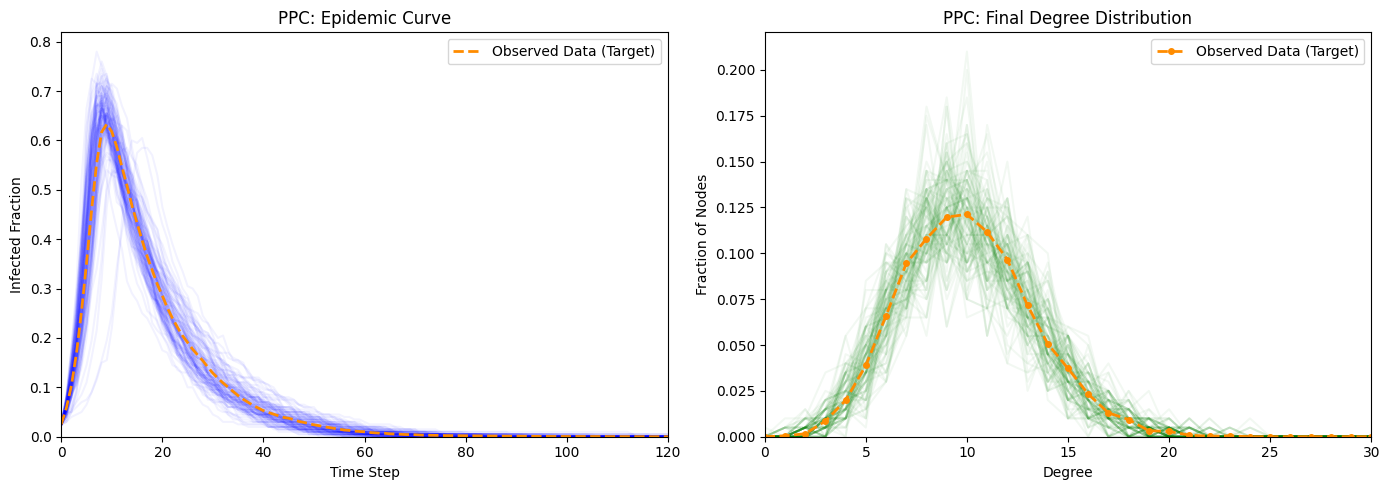

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("--- Starting Posterior Predictive Check (PPC) ---")

# 1. Sample 100 parameter sets from the adjusted posterior distribution
sample_size = 100
sampled_params = df_adjusted.sample(n=sample_size, random_state=42)[['beta', 'gamma', 'rho']].values

sim_infected_list = []
sim_degrees_list = []

# 2. Run simulations using the sampled parameters
for beta, gamma, rho in sampled_params:
    sim_inf, _, sim_deg = simulate_fast(beta, gamma, rho)
    sim_infected_list.append(sim_inf)
    sim_degrees_list.append(sim_deg)

# 3. Aggregate mean values of the observed data (target)
# Mean of the epidemic curves
obs_inf_mean = obs_infected.groupby('time')['infected_fraction'].mean().values
obs_inf_time = np.sort(obs_infected['time'].unique())

# Mean of the final degree distribution (converted to fractions)
obs_deg_mean = obs_degrees.groupby('degree')['count'].mean().values / 200
obs_deg_x = np.sort(obs_degrees['degree'].unique())

# 4. Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) Epidemic Curve
for sim_inf in sim_infected_list:
    axes[0].plot(sim_inf, color='blue', alpha=0.05) # Plot 100 predictions in faint blue
# Overlay the observed data on top
axes[0].plot(obs_inf_time, obs_inf_mean, color='darkorange', linewidth=2, label='Observed Data (Target)', linestyle='--')
axes[0].set_title('PPC: Epidemic Curve')
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Infected Fraction')
axes[0].set_xlim(0, 120)
axes[0].set_ylim(bottom=0)
axes[0].legend()

# (2) Final Degree Distribution
for sim_deg in sim_degrees_list:
    axes[1].plot(np.arange(31), sim_deg / 200, color='green', alpha=0.05) # Plot 100 predictions in faint green
# Overlay the observed data on top
axes[1].plot(obs_deg_x, obs_deg_mean, color='darkorange', linewidth=2, label='Observed Data (Target)', marker='o', markersize=4, linestyle='--')
axes[1].set_title('PPC: Final Degree Distribution')
axes[1].set_xlabel('Degree')
axes[1].set_ylabel('Fraction of Nodes')
axes[1].set_xlim(0, 30)
axes[1].set_ylim(bottom=0)
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/smc_abc_ppc_plot.pdf', format='pdf', bbox_inches='tight')
print("Saved PPC plot to: plots/smc_abc_ppc_plot.pdf")

plt.show()

In [20]:

from sklearn.metrics import mean_squared_error

print("=== Quantitative PPC ===\n")

# --- 1. Evaluation of the Epidemic Curve (Infected Fraction) ---
sim_inf_array = np.array(sim_infected_list) # shape: (100, 120)
inf_lower = np.percentile(sim_inf_array, 2.5, axis=0)
inf_upper = np.percentile(sim_inf_array, 97.5, axis=0)
inf_mean = np.mean(sim_inf_array, axis=0)

# Check if the observed mean curve is within the 95% prediction interval at each time step
inf_coverage = np.mean((obs_inf_mean >= inf_lower) & (obs_inf_mean <= inf_upper)) * 100
# The RMSE between the observed mean curve and the mean of the simulated curves
inf_rmse = np.sqrt(mean_squared_error(obs_inf_mean, inf_mean))

print("【 Epidemic Curve 】")
print(f"  [95% Prediction Interval Coverage]: {inf_coverage:.1f}%")
print(f"  [Prediction Error (RMSE)]: {inf_rmse:.5f}")
print("-" * 60)

# --- 2. Evaluation of the Final Degree Distribution ---
# Calculate the 2.5%, mean, and 97.5% percentiles for each degree (converted to fractions)
sim_deg_array = np.array(sim_degrees_list) / 200 # shape: (100, 31)
deg_lower = np.percentile(sim_deg_array, 2.5, axis=0)
deg_upper = np.percentile(sim_deg_array, 97.5, axis=0)
deg_mean = np.mean(sim_deg_array, axis=0)

# Check if the observed mean degree distribution is within the 95% prediction interval for each degree
deg_coverage = np.mean((obs_deg_mean >= deg_lower) & (obs_deg_mean <= deg_upper)) * 100
deg_rmse = np.sqrt(mean_squared_error(obs_deg_mean, deg_mean))

print("【 Final Degree Distribution 】")
print(f"  [95% Prediction Interval Coverage]: {deg_coverage:.1f}%")
print(f"  [Prediction Error (RMSE)]: {deg_rmse:.5f}")
print("-" * 60)

=== Quantitative PPC ===

【 Epidemic Curve 】
  [95% Prediction Interval Coverage]: 100.0%
  [Prediction Error (RMSE)]: 0.00455
------------------------------------------------------------
【 Final Degree Distribution 】
  [95% Prediction Interval Coverage]: 100.0%
  [Prediction Error (RMSE)]: 0.00190
------------------------------------------------------------
